In [1]:
import numpy as np
import pandas as pd

In [2]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("final_merge.csv")

In [5]:
df.columns

Index(['pages', 'publishDate', 'likedPercent', 'price', 'description',
       'characters', 'awards', 'length', 'numofchar', 'numofawards', 'title',
       'author', 'bbeScore', 'series', 'language', 'bookFormat', 'edition',
       'publisher', 'coverImg', 'bookId', 'genres', 'ratingsByStars',
       'bbeVotes', 'isbn', 'isSeries', 'formatCategory', 'rating',
       'numRatings'],
      dtype='str')

## Calculation of Custom Popularity Score

In [6]:
df[['numRatings','bbeVotes','likedPercent']].corr()

,numRatings,bbeVotes,likedPercent
numRatings,1.000000,0.719141,0.013401
bbeVotes,0.719141,1.000000,0.005731
likedPercent,0.013401,0.005731,1.000000


In [7]:
df['bbeVotes'].describe()

count    52376.000000
mean        22.573411
std        369.516455
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max      30516.000000
Name: bbeVotes, dtype: float64

In [8]:
from sklearn.preprocessing import MinMaxScaler

In [9]:
scaler = MinMaxScaler()

df[['numRatings_norm','bbeVotes_norm','likedPercent_norm']] = \
    scaler.fit_transform(df[['numRatings','bbeVotes','likedPercent']])

df['popularity_score'] = (
    0.7 * df['numRatings_norm'] +
    0.2 * df['bbeVotes_norm'] +
    0.1 * df['likedPercent_norm']
)

In [10]:
df['popularity_score'].describe()

count    52376.000000
mean         0.094179
std          0.013634
min          0.000007
25%          0.091014
50%          0.094328
75%          0.097162
max          0.929293
Name: popularity_score, dtype: float64

## Top 10 Most Popular Books

In [11]:
#top 10 books sorted by popularity score 
top10 = df.sort_values(by='popularity_score', ascending=False).head(10)

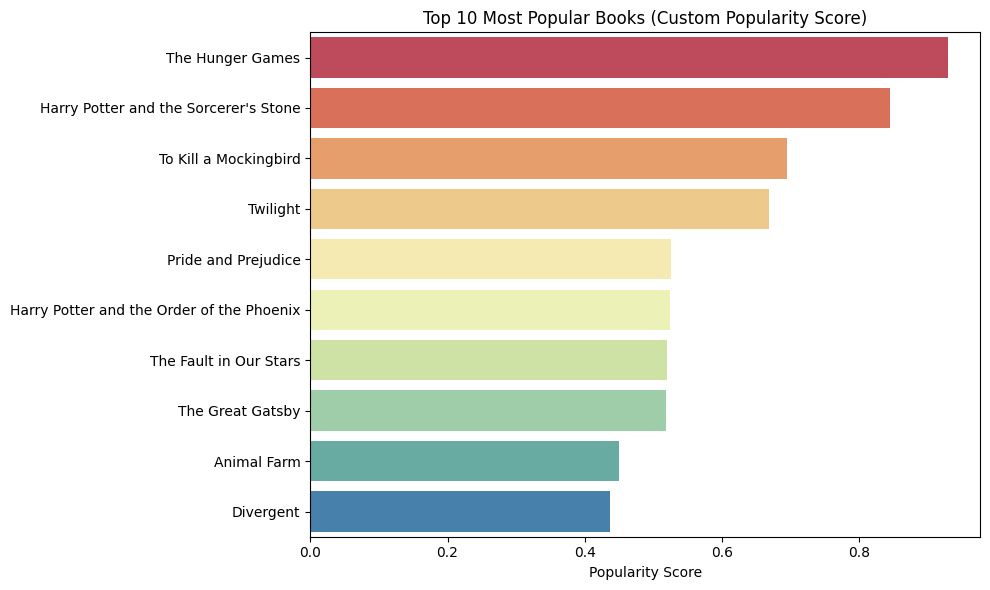

In [12]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='popularity_score',
    y='title',
    data=top10,
    hue='title',
    palette='Spectral',
    legend=False
)

plt.title('Top 10 Most Popular Books (Custom Popularity Score)')
plt.xlabel('Popularity Score')
plt.ylabel('')

plt.tight_layout()
plt.show()

#### Insight: 

## Market Performance vs Reader Satisfaction by Genre

In [13]:
df_genre = df.copy()

In [14]:
#replacing empty lists with None
df_genre['genres'] = df_genre['genres'].replace('[]', None)
df_genre = df_genre[df_genre['genres'].notna()]

In [15]:
#converting to lists again
import ast
df_genre['genres'] = df_genre['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [16]:
type(df_genre['genres'].iloc[0]) #testing

list

In [17]:
#exploding genres lists into individual entities 
# pd.set_option('display.max_columns', None)
df_genre = df_genre.explode('genres')

In [18]:
df_genre[['title','genres']].head(10)

,title,genres
0,The Hunger Games,Young Adult
0,The Hunger Games,Fiction
0,The Hunger Games,Dystopia
0,The Hunger Games,Fantasy
0,The Hunger Games,Science Fiction
0,The Hunger Games,Romance
0,The Hunger Games,Adventure
0,The Hunger Games,Teen
0,The Hunger Games,Post Apocalyptic
0,The Hunger Games,Action


In [19]:
#grouping genres by their average liked percent, popularity score and total count of each genre
genre_summary = (
    df_genre.groupby('genres').agg(
        genre_count=('title','count'),
        avg_popularity_score=('popularity_score','mean'),
        avg_likedPercent=('likedPercent','mean')
    ).reset_index()
)

In [20]:
#filtering only those genres that have more than 50 books
genre_summary = genre_summary[genre_summary['genre_count'] >= 50]

In [21]:
genre_summary

,genres,genre_count,avg_popularity_score,avg_likedPercent
6,16th Century,86,0.093173,92.290698
7,17th Century,93,0.092005,91.096774
8,18th Century,183,0.091313,90.071038
9,19th Century,835,0.095274,91.665868
11,20th Century,1954,0.093519,92.322927
...,...,...,...,...
970,Young Adult Fantasy,1149,0.095621,92.387293
971,Young Adult Historical Fiction,57,0.092690,92.245614
972,Young Adult Paranormal,111,0.091787,91.162162
973,Young Adult Romance,325,0.092808,90.501538


In [22]:
#the top 15 genres by count/frequency
top_genres = genre_summary.sort_values(
    by='genre_count', ascending=False
).head(15)
top_genres.reset_index()

,index,genres,genre_count,avg_popularity_score,avg_likedPercent
0,330,Fiction,31604,0.094816,92.073596
1,755,Romance,15481,0.094087,91.849567
2,318,Fantasy,15036,0.095252,92.370710
3,968,Young Adult,11856,0.094910,91.815383
4,210,Contemporary,10507,0.093656,91.271032
5,646,Nonfiction,8244,0.094422,93.050218
6,23,Adult,8240,0.096097,92.387379
7,651,Novels,7798,0.094694,91.112978
8,620,Mystery,7690,0.094579,92.223508
9,439,Historical Fiction,7658,0.095196,92.486028


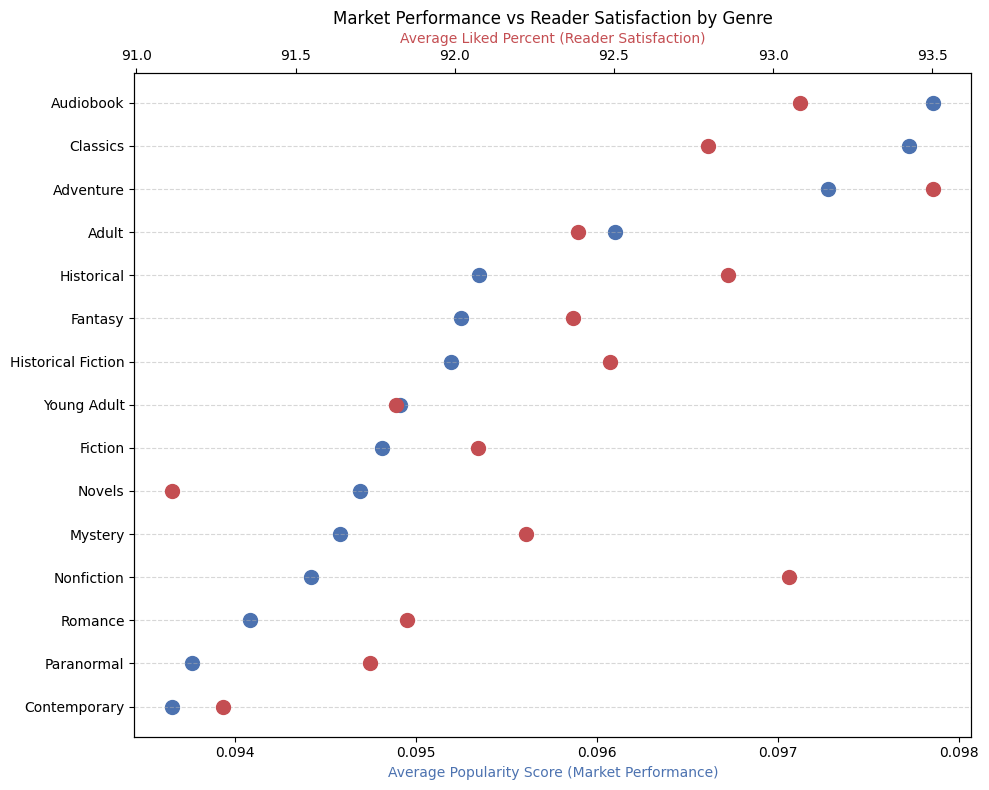

In [23]:
# sort first by popularity score
top_genres = top_genres.sort_values(
    by='avg_popularity_score', ascending=True
)

fig, ax1 = plt.subplots(figsize=(10,8))

# create second x-axis
ax2 = ax1.twiny()

y_positions = range(len(top_genres))

# market performance (bottom axis)
ax1.scatter(
    top_genres['avg_popularity_score'],
    y_positions,
    color='#4c72b0',
    s=100,
    label='Market Performance'
)

# reader satisfaction (top axis)
ax2.scatter(
    top_genres['avg_likedPercent'],
    y_positions,
    color='#c44e52',
    s=100,
    label='Reader Satisfaction'
)

# Y-axis labels
ax1.set_yticks(y_positions)
ax1.set_yticklabels(top_genres['genres'])

# Axis labels
ax1.set_xlabel('Average Popularity Score (Market Performance)', color='#4c72b0')
ax2.set_xlabel('Average Liked Percent (Reader Satisfaction)', color='#c44e52')

ax1.set_title('Market Performance vs Reader Satisfaction by Genre')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Series vs Standalone Books by Popularity

In [24]:
#total count of series books and standalone books
df['isSeries'].value_counts()

isSeries
False    28983
True     23445
Name: count, dtype: int64

In [25]:
df['isSeries'].dtype

dtype('bool')

In [26]:
#Grouping the two categories by popularity score mean and rating mean (avg)
series_summary = df.groupby('isSeries')[['popularity_score', 'rating']].mean().reset_index()

In [27]:
series_summary #extremely minute difference btw

,isSeries,popularity_score,rating
0,False,0.093199,3.995714
1,True,0.095390,4.054192


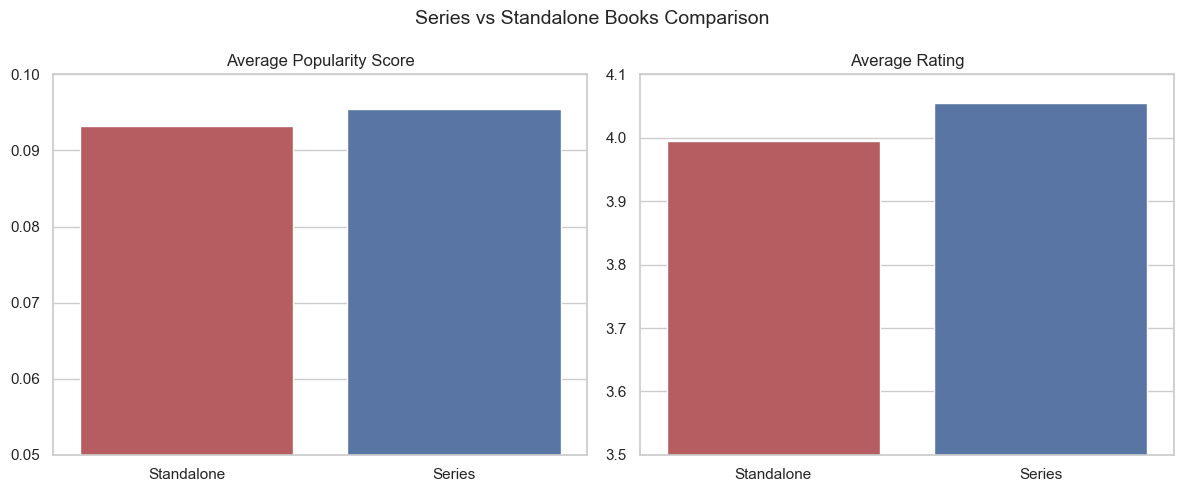

In [28]:
sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 2, figsize=(12,5))

#limiting range of both y axes to zoom in on the differences
axes[0].set_ylim(0.05, 0.1)
axes[1].set_ylim(3.50, 4.10)

# Popularity chart
sns.barplot(
    data=series_summary,
    x="isSeries",
    y="popularity_score",
    hue="isSeries",
    palette=["#c44e52", "#4c72b0"],
    ax=axes[0],
    legend=False
)

axes[0].set_xticks([0,1])
axes[0].set_xticklabels(["Standalone","Series"])
axes[0].set_title("Average Popularity Score")
axes[0].set_xlabel("")
axes[0].set_ylabel("")


# Rating chart
sns.barplot(
    data=series_summary,
    x="isSeries",
    y="rating",
    hue="isSeries",
    palette=["#c44e52", "#4c72b0"],
    legend=False,
    ax=axes[1]
)

axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["Standalone","Series"])
axes[1].set_title("Average Rating")
axes[1].set_xlabel("")
axes[1].set_ylabel("")


plt.suptitle("Series vs Standalone Books Comparison", fontsize=14)

plt.tight_layout()
plt.show()

## Popularity Comparison within Major Book Series

In [29]:
#sorting the values by bbeScore and isSeries, only for viewing...not assigned to the original df
df.sort_values(by=['bbeScore','isSeries'], ascending=[False, False]).head(20)

,pages,publishDate,likedPercent,price,description,characters,awards,length,numofchar,numofawards,...,bbeVotes,isbn,isSeries,formatCategory,rating,numRatings,numRatings_norm,bbeVotes_norm,likedPercent_norm,popularity_score
0,374,2008-09-14 00:00:00.000000000,96.0,1.806648,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"["" 'Katniss Everdeen'"", "" 'Peeta Mellark'"", "" ...","["" 'Locus Award Nominee for Best Young Adult B...",Short Book,23,41.0,...,30516.0,9780439023481,True,Hardcover,4.33,6376780,0.904704,1.000000,0.96,0.929293
1,870,2004-09-28 00:00:00.000000000,98.0,2.125848,There is a door at the end of a silent corrido...,"["" 'Sirius Black'"", "" 'Draco Malfoy'"", "" 'Ron ...","["" 'Bram Stoker Award for Works for Young Read...",Long Book,44,9.0,...,26923.0,9780439358071,True,Paperback,4.50,2507623,0.355768,0.882258,0.98,0.523490
2,324,2006-05-23 00:00:00.000000000,95.0,1.824549,The unforgettable novel of a childhood in a sl...,"["" 'Scout Finch'"", "" 'Atticus Finch'"", "" 'Jem ...","["" 'Pulitzer Prize for Fiction (1961)'"", "" 'Au...",Short Book,14,4.0,...,23328.0,9999999999999,True,Paperback,4.28,4501075,0.638589,0.764451,0.95,0.694902
3,279,2000-10-10 00:00:00.000000000,94.0,1.824549,Alternate cover edition of ISBN 9780679783268S...,"["" 'Mr. Bennet'"", "" 'Mrs. Bennet'"", "" 'Jane Be...",['No awards'],Short Book,24,NaN,...,20452.0,9999999999999,False,Paperback,4.26,2998241,0.425375,0.670206,0.94,0.525803
4,501,2006-09-06 00:00:00.000000000,78.0,1.131402,About three things I was absolutely positive.\...,"["" 'Edward Cullen'"", "" 'Jacob Black'"", "" 'Laur...","["" 'Georgia Peach Book Award (2007)'"", "" 'Buxt...",Standard Book,17,25.0,...,14874.0,9780316015844,True,Paperback,3.60,4964519,0.704340,0.487416,0.78,0.668521
5,552,2006-03-14 00:00:00.000000000,96.0,1.568616,Librarian's note: An alternate cover edition c...,"["" 'Liesel Meminger'"", "" 'Hans Hubermann'"", "" ...","["" 'National Jewish Book Award for Children’s ...",Standard Book,8,20.0,...,14168.0,9780375831003,False,Hardcover,4.37,1834276,0.260237,0.464281,0.96,0.371022
6,141,1996-04-28 00:00:00.000000000,91.0,1.690096,Librarian's note: There is an Alternate Cover ...,"["" 'Snowball'"", "" 'Napoleon'"", "" 'Clover'"", "" ...","["" 'Prometheus Hall of Fame Award (2011)'"", "" ...",Short Book,10,2.0,...,13264.0,9780451526342,False,Paperback,3.95,2740713,0.388838,0.434657,0.91,0.450118
7,767,2002-09-16 00:00:00.000000000,96.0,1.824549,"Journeys to the end of the world, fantastic cr...","["" 'Polly'"", "" 'Aslan'"", "" 'Lucy Pevensie'"", ""...",['No awards'],Standard Book,30,NaN,...,12949.0,9999999999999,True,Paperback,4.26,517740,0.073454,0.424335,0.96,0.232285
8,1,2012-09-25 00:00:00.000000000,98.0,3.097837,"This four-volume, boxed set contains J.R.R. To...","["" 'Frodo Baggins'"", "" 'Gandalf'"", "" 'Bilbo Ba...",['No awards'],Short Book,4,NaN,...,12111.0,9780345538376,True,Paperback,4.60,110146,0.015627,0.396874,0.98,0.188314
9,1037,1999-04-01 00:00:00.000000000,94.0,1.884035,"Scarlett O'Hara, the beautiful, spoiled daught...","[' ""Scarlett O\'Hara""', "" 'Rhett Butler'"", "" '...","["" 'Pulitzer Prize for Novel (1937)'"", "" 'Nati...",Long Book,29,2.0,...,11211.0,9780446675536,False,Paperback,4.30,1074620,0.152461,0.367381,0.94,0.274199


In [30]:
df['series'].str.contains("Harry Potter").value_counts() #how many books a popular series has, manual checking for a few

series
False    52412
True        16
Name: count, dtype: int64

In [31]:
df['series'].str.contains("The Hunger Games").value_counts()

series
False    52420
True         8
Name: count, dtype: int64

In [32]:
df['series'].str.contains("Sherlock Holmes").value_counts()

series
False    52372
True        56
Name: count, dtype: int64

In [33]:
df['series'].str.contains("Lord of the Rings").value_counts()

series
False    52421
True         7
Name: count, dtype: int64

In [34]:
#copying the filtered series names to a new list then making a df to only include the books belonging to any of these series
series_list = ["Harry Potter", "Percy Jackson", "The Hunger Games", "Death Note", "The Chronicles of Narnia", "The Lord of the Rings"]
df_series = df[df['series'].str.contains('|'.join(series_list), na=False)].copy()

In [35]:
df_series['series'].unique()

<StringArray>
[                                            'The Hunger Games #1',
                                                 'Harry Potter #5',
               'The Chronicles of Narnia (Publication Order) #1–7',
                                      'The Lord of the Rings #0-3',
                                                 'Harry Potter #1',
                              'Percy Jackson and the Olympians #1',
                                                 'Harry Potter #7',
                                        'The Lord of the Rings #1',
                                                 'Harry Potter #3',
                                                 'Harry Potter #4',
                                                 'Harry Potter #6',
                                                 'Harry Potter #2',
                 'The Chronicles of Narnia (Publication Order) #1',
                              'Percy Jackson and the Olympians #5',
                              'Per

In [36]:
#removing unnecessary books (box editions etc)
df_series = df_series[df_series['series'].str.contains(r'#\d+$', regex=True)]

In [37]:
#extracting the book number for proper sorting
df_series['book_number'] = df_series['series'].str.extract(r'#(\d+)').astype(int)

In [38]:
df_series['book_number'].count()

np.int64(53)

In [39]:
#new column with cleaned names of the series
df_series['series_clean'] = df_series['series'].str.extract(
    r'(Harry Potter|Death Note|Percy Jackson|The Hunger Games|The Chronicles of Narnia|The Lord of the Rings)'
)

In [40]:
#sorting the series df by names of the series and their book number
df_series = df_series.sort_values(['series_clean','book_number'])

In [41]:
df_series[['series_clean', 'book_number', 'title']]

,series_clean,book_number,title
1541,Death Note,1,"Death Note, Vol. 1: Boredom"
9089,Death Note,1,"Death Note: Black Edition, Vol. 1"
5141,Death Note,2,"Death Note, Vol. 2: Confluence"
37380,Death Note,2,"Death Note: Black Edition, Vol. 2"
8118,Death Note,3,"Death Note, Vol. 3: Hard Run"
36720,Death Note,3,"Death Note: Black Edition, Vol. 3"
6256,Death Note,4,"Death Note, Vol. 4: Love"
36013,Death Note,4,"Death Note: Black Edition, Vol. 4"
5584,Death Note,5,"Death Note, Vol. 5: Whiteout"
35204,Death Note,5,"Death Note: Black Edition, Vol. 5"


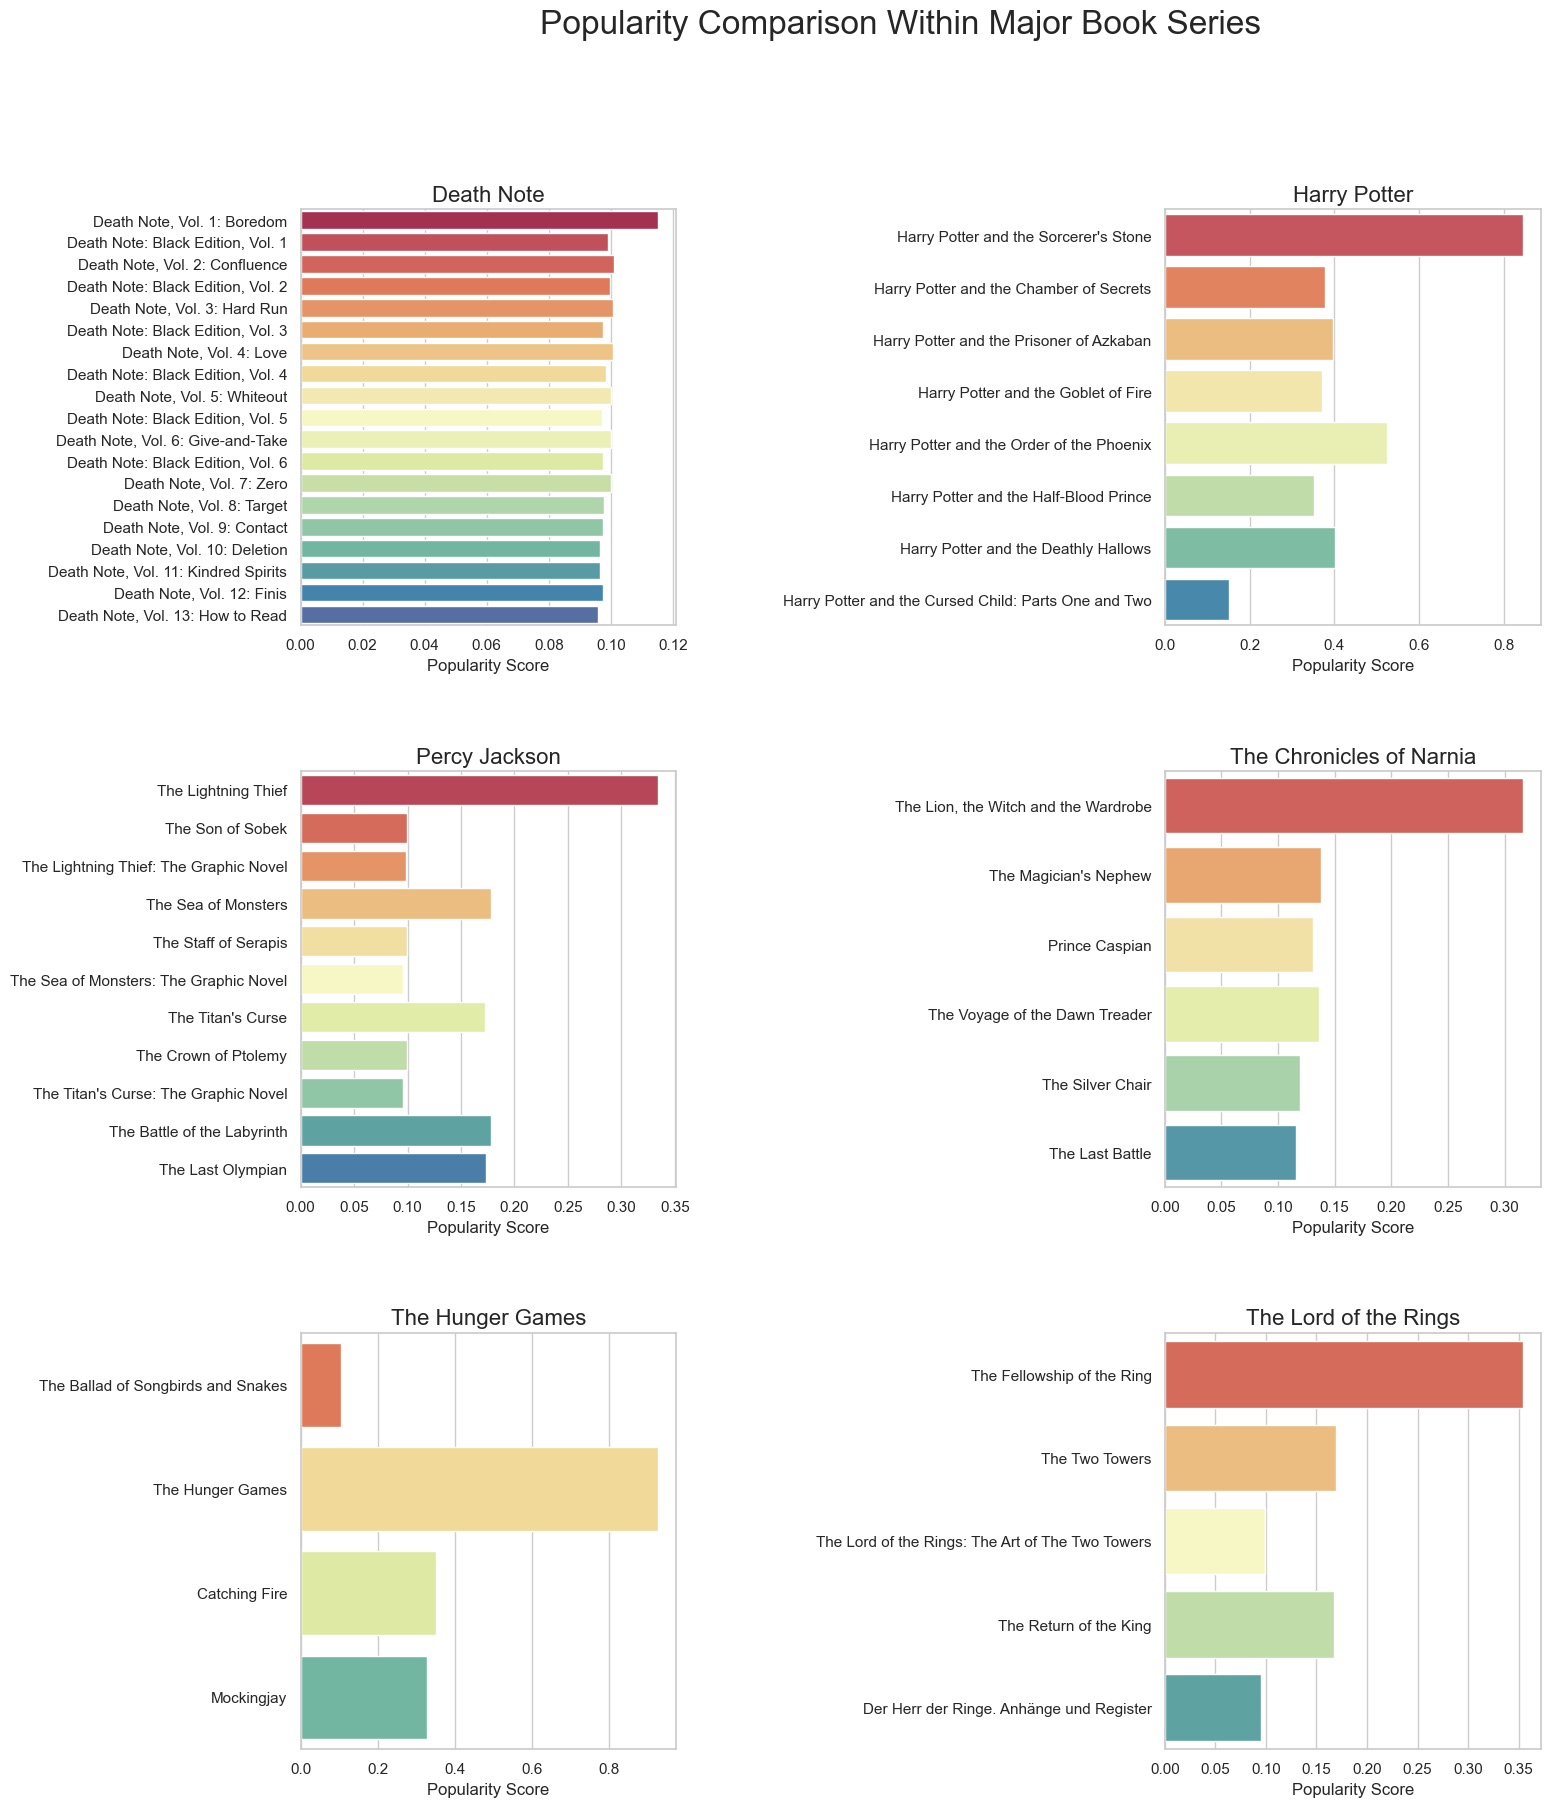

In [42]:
sns.set_theme(style="whitegrid", context="notebook")

series_list = df_series['series_clean'].unique()

fig, axes = plt.subplots(3, 2, figsize=(16, 20))
axes = axes.flatten()

for i, series in enumerate(series_list):

    data = df_series[df_series['series_clean'] == series].sort_values("book_number")

    sns.barplot(
        data=data,
        x="popularity_score",
        y="title",
        ax=axes[i],
        hue="title",
        palette="Spectral",
        legend=False
    )
    
    axes[i].set_title(series, fontsize=16)
    axes[i].set_xlabel("Popularity Score")
    axes[i].set_ylabel("")

plt.suptitle(
    "Popularity Comparison Within Major Book Series",
    fontsize=24
)

# plt.tight_layout()
plt.subplots_adjust(
    hspace=0.35,   # vertical space between rows
    wspace=1.30    # horizontal space between columns
)
plt.show()

##### NOTE: Character-level analysis was explored but did not produce meaningful variation in popularity metrics across characters, therefore it was excluded from the final visual analysis.

## Top Authors based on the Number of Books

In [43]:
df['author'].dtype

<StringDtype(storage='python', na_value=nan)>

In [44]:
df['author'].head(20)

0                                       Suzanne Collins
1             J.K. Rowling, Mary GrandPré (Illustrator)
2                                            Harper Lee
3             Jane Austen, Anna Quindlen (Introduction)
4                                       Stephenie Meyer
5                       Markus Zusak (Goodreads Author)
6     George Orwell, Russell Baker (Preface), C.M. W...
7              C.S. Lewis, Pauline Baynes (Illustrator)
8                                        J.R.R. Tolkien
9                                     Margaret Mitchell
10                        John Green (Goodreads Author)
11                                        Douglas Adams
12                                     Shel Silverstein
13    Emily Brontë, Richard J. Dunn (Editor), David ...
14                         Dan Brown (Goodreads Author)
15                                        Arthur Golden
16        Oscar Wilde, Jeffrey Eugenides (Introduction)
17    Lewis Carroll, John Tenniel (Illustrator),

In [45]:
df_auth = df.copy()

In [46]:
#splitting multiple author names by comma as delimiter
df_auth['author'] = df['author'].str.split(",")

In [47]:
#explode to make individual author per book
df_auth = df_auth.explode("author")

In [48]:
#remove whitespaces
df_auth['author'] = df_auth['author'].str.strip()

In [49]:
#removing any special character like parenthesis etc. from author names
df_auth["author"] = df_auth["author"].str.replace(r"\s*\(.*?\)", "", regex=True)
df_auth['author'].head()

0    Suzanne Collins
1       J.K. Rowling
1      Mary GrandPré
2         Harper Lee
3        Jane Austen
Name: author, dtype: str

In [50]:
#counting the total number of books per author
author_count = df_auth['author'].value_counts().reset_index()

In [51]:
#renaming the columns
author_count.columns = ["author", "book_count"]

In [52]:
author_count.head(20)

,author,book_count
0,more…,196
1,Stephen King,112
2,James Patterson,104
3,Nora Roberts,104
4,Agatha Christie,89
5,Anonymous,84
6,Erin Hunter,81
7,Neil Gaiman,71
8,Terry Pratchett,69
9,Meg Cabot,65


In [53]:
author_count = author_count.drop(0) #remove unwanted row having "more..." as author
author_count = author_count.drop(5) #remove unwanted row having "Anonymous" as author

In [54]:
#store the top 15 authors in another df
top_authors = author_count.head(15)

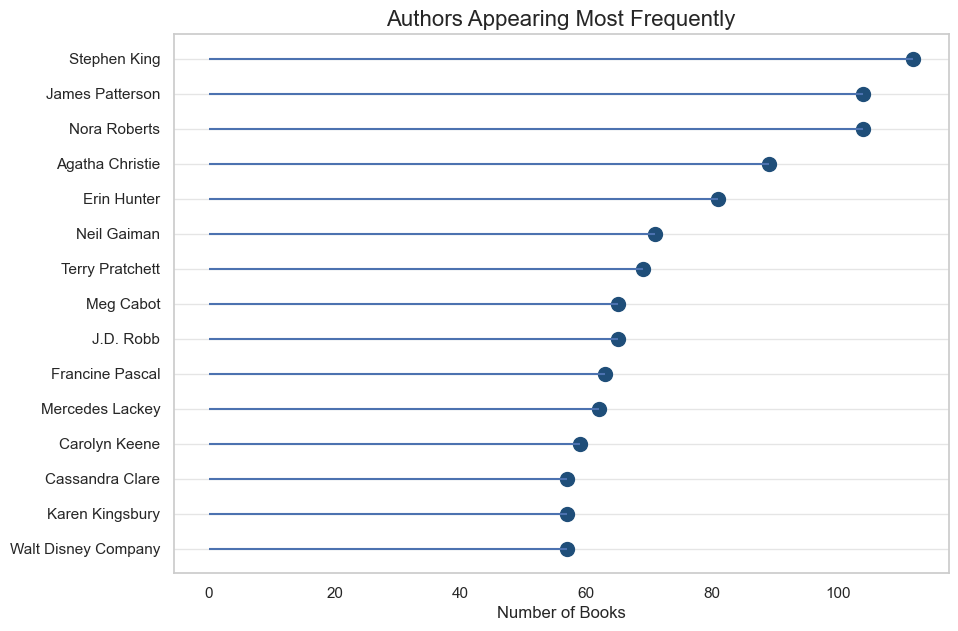

In [55]:
plt.figure(figsize=(10,7))

plt.hlines(
    y=top_authors["author"],
    xmin=0,
    xmax=top_authors["book_count"],
    color="#4c72b0"
)

plt.scatter(
    top_authors["book_count"],
    top_authors["author"],
    color="#1f4e79",
    s=100
)

plt.title("Authors Appearing Most Frequently", fontsize='16')
plt.xlabel("Number of Books")
plt.ylabel("")

plt.gca().invert_yaxis()
plt.grid(axis='y', alpha=0.5)
plt.grid(axis='x', visible=False)
# plt.tight_layout()
plt.show()

## Book Performance across Decades

In [56]:
#make a new df and convert the column "publishDate" to string to strip any of the whitespaces it may have
df_year = df
df_year['publishDate'] = df_year['publishDate'].astype(str).str.strip()

In [57]:
# Convert the string column back to datetime 
df_year['publishDate'] = pd.to_datetime(df_year['publishDate'], format='mixed', errors='coerce')
df_year['publishDate'].tail()

52423   2011-05-28
52424   2011-08-05
52425   2011-03-18
52426   2011-09-01
52427   2011-05-08
Name: publishDate, dtype: datetime64[ns]

In [58]:
# Extract just the year
df_year['year'] = df_year['publishDate'].dt.year

In [59]:
# Convert the year to an integer.
df_year['year'] = df_year['year'].astype('Int64')

In [60]:
df_year['year'] # working perfectly fine

0        2008
1        2004
2        2006
3        2000
4        2006
         ... 
52423    2011
52424    2011
52425    2011
52426    2011
52427    2011
Name: year, Length: 52428, dtype: Int64

In [61]:
# Create a decade column using floor division
df_year['decade'] = (df_year['year'] // 10) * 10

In [62]:
# To check which decades have good sample size of books to analyse from
df_year['decade'].value_counts()

decade
2010    22530
2000    20261
1990     6095
1980     1883
1970      774
2020      410
1960      289
1950       97
1940       27
1930       23
1920       17
1900        9
1910        5
1880        4
1890        2
1870        1
1820        1
Name: count, dtype: Int64

In [63]:
# Only keeping the decades from 1950 till 2020
df_decade = df_year[(df_year["decade"] >= 1950) & (df_year["decade"] <= 2020)]

In [64]:
# create a new df by grouping the decades by their average rating, likedPercent and popularity_score
decade_summary = (df_decade.groupby("decade")[["rating", "likedPercent", "popularity_score"]].mean().reset_index())

In [65]:
decade_summary

,decade,rating,likedPercent,popularity_score
0,1950,4.045361,93.721649,0.094279
1,1960,3.998997,93.256055,0.093727
2,1970,4.038023,93.126615,0.094935
3,1980,4.025003,93.206585,0.094630
4,1990,3.999733,92.726497,0.094612
5,2000,3.982840,92.002024,0.094505
6,2010,4.057368,92.171904,0.093684
7,2020,4.297220,94.939024,0.095860


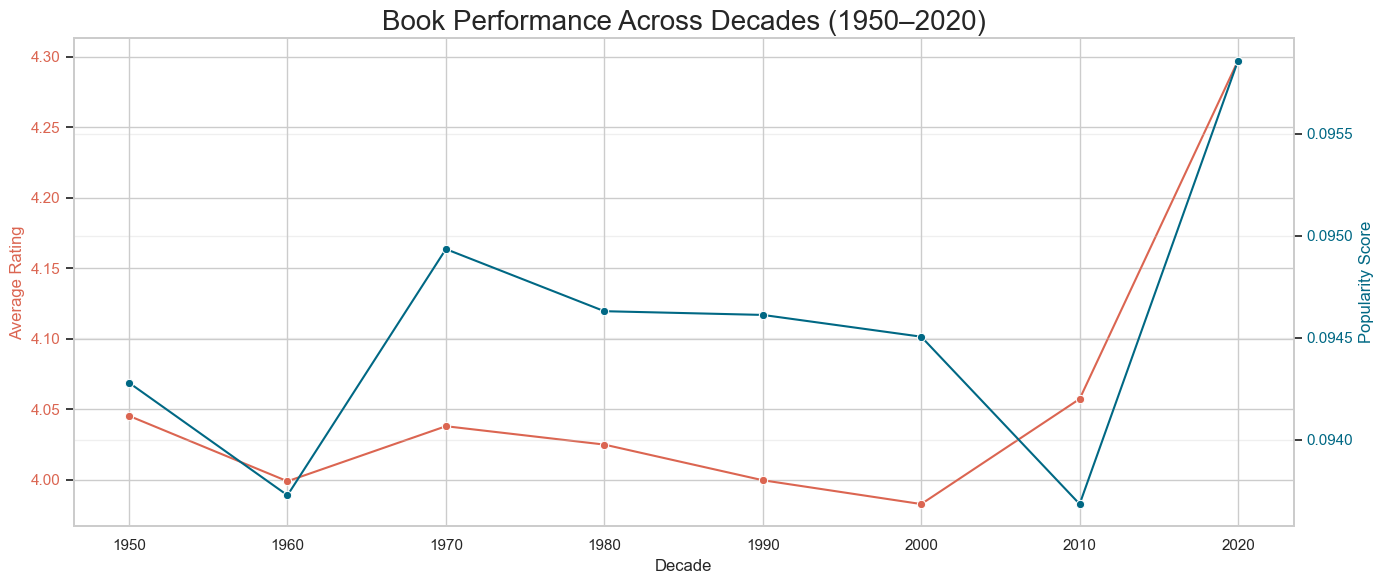

In [66]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Rating line
sns.lineplot(
    data=decade_summary,
    x="decade",
    y="rating",
    marker="o",
    color="#db6551",
    ax=ax1
)

ax1.set_ylabel("Average Rating", color="#db6551")
ax1.tick_params(axis='y', labelcolor="#db6551")

# second axis
ax2 = ax1.twinx()

sns.lineplot(
    data=decade_summary,
    x="decade",
    y="popularity_score",
    marker="o",
    color="#006884",
    ax=ax2
)

ax2.set_ylabel("Popularity Score", color="#006884")
ax2.tick_params(axis='y', labelcolor="#006884")

ax1.set_xlabel("Decade")
plt.title("Book Performance Across Decades (1950–2020)", fontsize=20)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Does language affect ratings or popularity?

In [67]:
# Looking at the total number of books each major language has
df['language'].value_counts().head(15)

language
English                  42635
Unknown                   3801
Arabic                    1036
Spanish                    684
French                     576
German                     525
Indonesian                 370
Portuguese                 363
Italian                    254
Dutch                      214
Turkish                    211
Persian                    164
Polish                     138
Greek, Modern (1453-)      112
Russian                     98
Name: count, dtype: int64

In [68]:
# Store the top 11 languages index (language names) in top_lang list
top_lang = df['language'].value_counts().head(11).index

In [69]:
top_lang=top_lang.drop("Unknown") # Drop unknown language books

In [70]:
# Create a new df containing only top language books
lang_df = df[df['language'].isin(top_lang)]

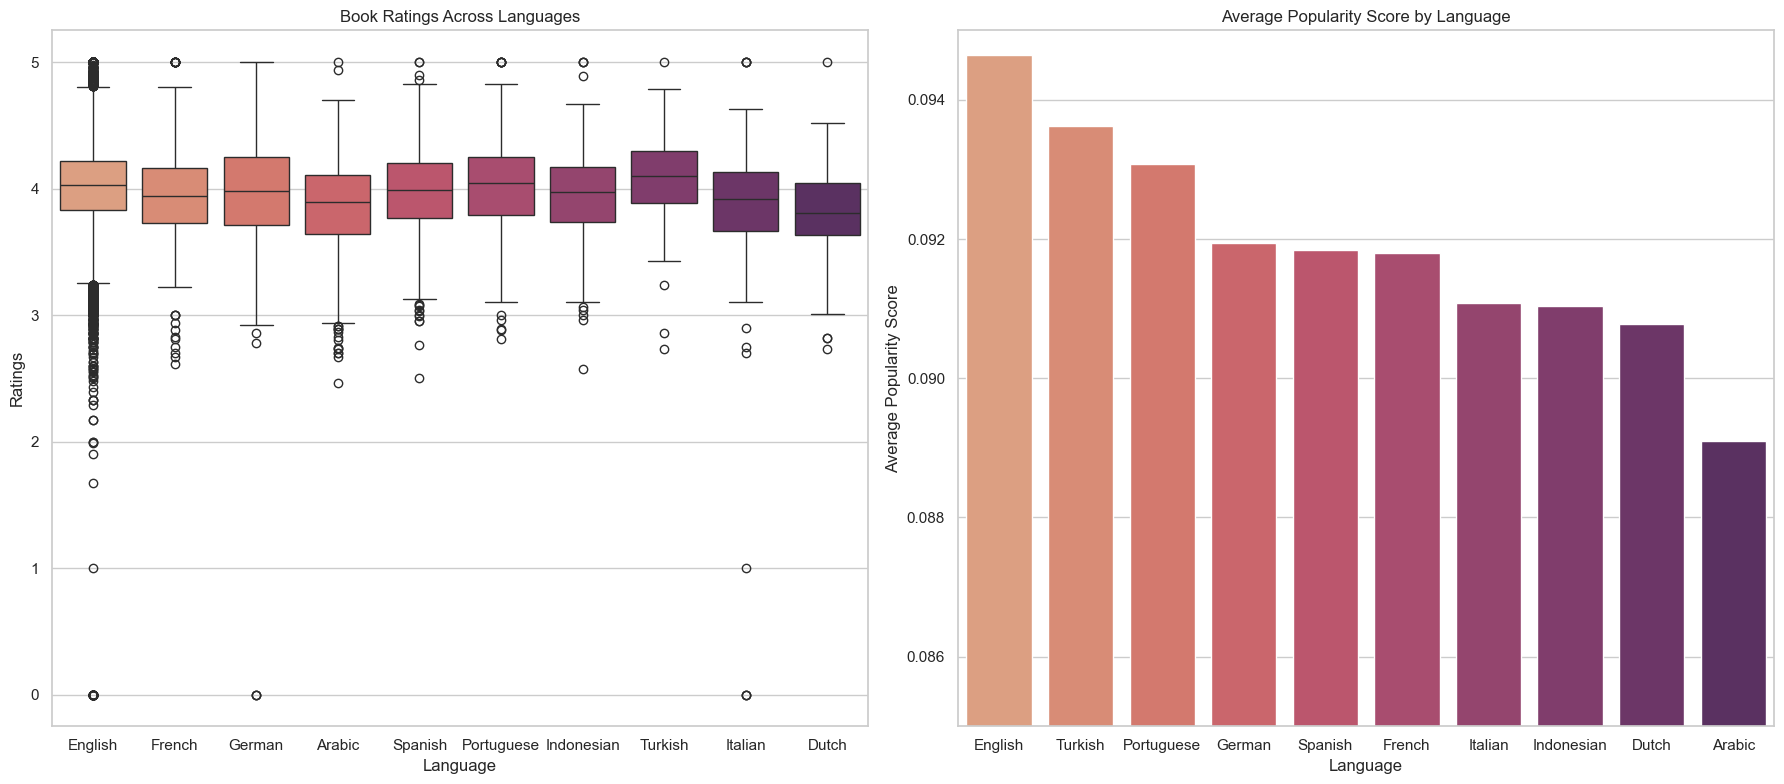

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(18,8))

# Ratings boxplot
sns.boxplot(data=lang_df, x='language', y='rating', ax=axes[0], hue='language', palette='flare', legend=False)
axes[0].set_title("Book Ratings Across Languages")
axes[0].set_xlabel("Language")
axes[0].set_ylabel("Ratings")

lang_popularity = (
    lang_df.groupby("language")["popularity_score"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(x=lang_popularity.index, y=lang_popularity.values, hue=lang_popularity.index, palette='flare', legend=False)
axes[1].set_title("Average Popularity Score by Language")
axes[1].set_xlabel("Language")
axes[1].set_ylabel("Average Popularity Score")

plt.ylim(0.085, 0.095)

plt.tight_layout()
plt.show()

## Publisher Output vs Average Rating

In [72]:
# Top 20 publishers by number of books published
df['publisher'].value_counts().head(20)

publisher
Unknown                                        3692
Vintage                                         572
HarperCollins                                   562
Penguin Books                                   430
Ballantine Books                                399
Bantam                                          369
Createspace Independent Publishing Platform     367
Pocket Books                                    314
Avon                                            311
Berkley                                         287
Del Rey                                         284
Tor Books                                       283
Penguin Classics                                282
HarperTeen                                      274
Simon Pulse                                     270
Grand Central Publishing                        263
St. Martin's Press                              238
Little, Brown Books for Young Readers           233
Harper Perennial                                229
Si

In [73]:
df_publisher = df #copy df

In [74]:
# Grouping publisher by mean and count of rating of their published books
publisher_ratings = df_publisher.groupby('publisher')["rating"].agg(["mean", "count"])

In [75]:
# Only keeping those publishers that have published atleast more than 25 books 
publisher_ratings = publisher_ratings[publisher_ratings['count'] >= 25]

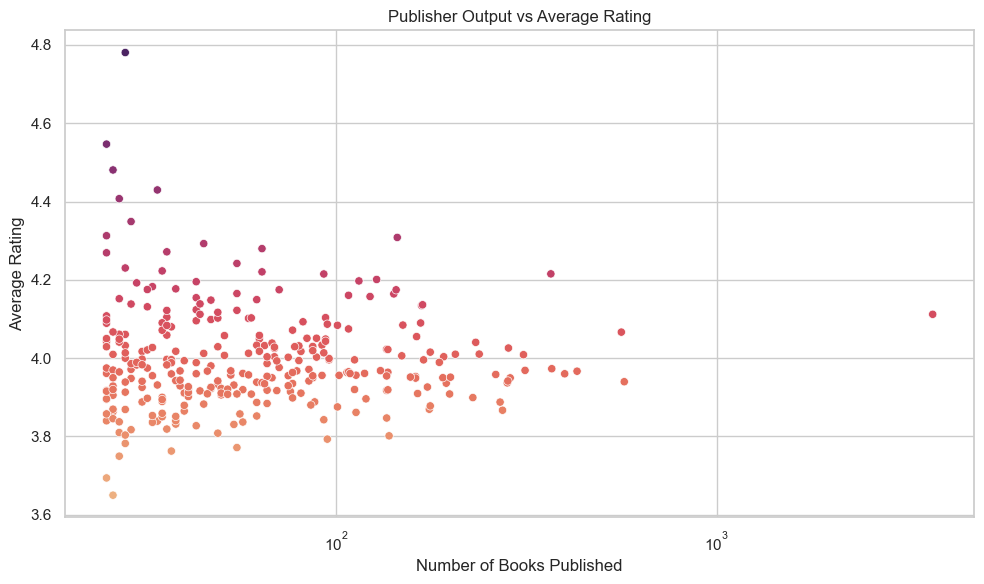

In [76]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=publisher_ratings, x='count', y='mean', hue='mean', legend=False, palette="flare")

plt.xlabel("Number of Books Published")
plt.ylabel("Average Rating")
plt.title("Publisher Output vs Average Rating")

plt.xscale("log")
plt.tight_layout()
plt.show()

## Relationship between Number of Ratings and Average Rating

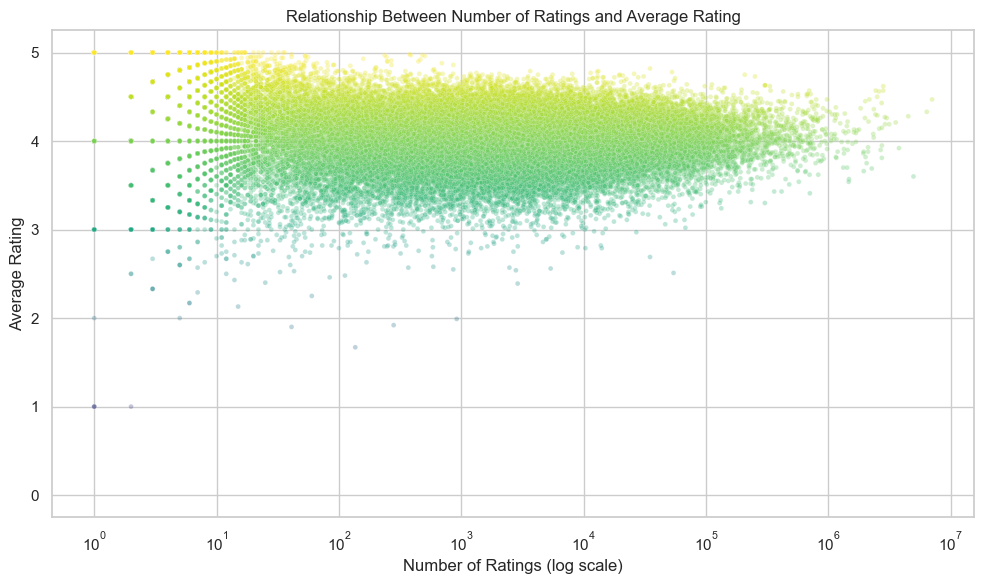

In [77]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="numRatings",
    y="rating",
    alpha=0.3,
    s=12,
    hue='rating',
    palette='viridis',
    legend=False
)

plt.xscale("log")

plt.title("Relationship Between Number of Ratings and Average Rating")
plt.xlabel("Number of Ratings (log scale)")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

In [78]:
df_year['year'] # using already extracted year column from df_year

0        2008
1        2004
2        2006
3        2000
4        2006
         ... 
52423    2011
52424    2011
52425    2011
52426    2011
52427    2011
Name: year, Length: 52428, dtype: Int64

###### Only for checking the sample size of books per year (Result concluded - More than 50 books is considered a good enough sample so only take years after 1970 for this analysis)


In [79]:
# df_sample = df_year.groupby("year")['title'].count()
# pd.set_option('display.max_rows', None)
# df_sample

In [80]:
# filtering only the years having more than 50 books
df_filt_year = df_year[(df_year['year']>=1970) & (df_year['year']<=2026)] 

In [81]:
# Grouping years by average price
year_price = df_filt_year.groupby("year")['price'].mean().reset_index()

In [82]:
year_price

,year,price
0,1970,2.004071
1,1971,2.433478
2,1972,1.978920
3,1973,2.158492
4,1974,2.234007
5,1975,2.066985
6,1976,2.005334
7,1977,2.006716
8,1978,2.056021
9,1979,1.892179


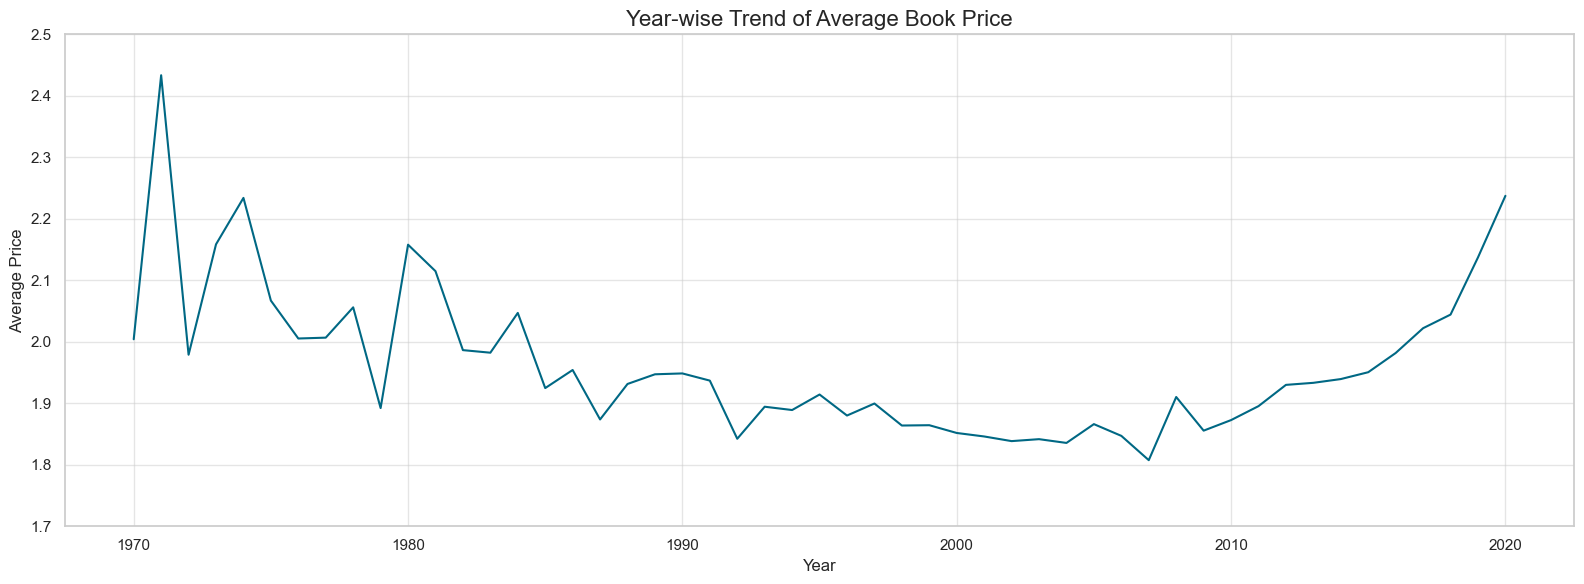

In [83]:
plt.figure(figsize=(16,6))

sns.lineplot(
    data=year_price,
    x="year",
    y="price",
    color="#006884"
)

plt.title("Year-wise Trend of Average Book Price", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Price", fontsize=12)

plt.ylim(1.7, 2.5)
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()